#### Imports

In [62]:
import os
from dotenv import load_dotenv
from sqlalchemy import create_engine, text
import pandas as pd
from sklearn.linear_model import LinearRegression
import numpy as np
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error, mean_squared_error

#### Starting Connection and Querying Data from Supabase

In [63]:
# Load environment variables from .env
load_dotenv()

# Fetch variables
USER = os.getenv("user")
PASSWORD = os.getenv("password")
HOST = os.getenv("host")
PORT = os.getenv("port")
DBNAME = os.getenv("dbname")

# Construct the SQLAlchemy connection string
DATABASE_URL = f"postgresql+psycopg2://{USER}:{PASSWORD}@{HOST}:{PORT}/{DBNAME}?sslmode=require"

# Create the SQLAlchemy engine
engine = create_engine(DATABASE_URL)
# If using Transaction Pooler or Session Pooler, we want to ensure we disable SQLAlchemy client side pooling -
# https://docs.sqlalchemy.org/en/20/core/pooling.html#switching-pool-implementations
# engine = create_engine(DATABASE_URL, poolclass=NullPool)

# Test the connection
try:
    with engine.connect() as connection:
        print("Connection successful!")
except Exception as e:
    print(f"Failed to connect: {e}")

Connection successful!


In [64]:
query = """
SELECT *
FROM "QBPointProjection"
WHERE season BETWEEN 2018 AND 2024
"""

qb_df = pd.read_sql(query, engine)

print(qb_df.shape)
qb_df.head()

(4305, 63)


,player_id,player_name,team,season,week,opponent_team,fantasy_points_ppr,attempts_prev,completions_prev,passing_yards_prev,...,rushing_fumbles_lost_roll5_mean,sack_fumbles_lost_lag1,sack_fumbles_lost_roll3_mean,sack_fumbles_lost_roll5_mean,pass_yards_allowed_roll3_mean,pass_yards_allowed_roll5_mean,pass_tds_allowed_roll3_mean,pass_tds_allowed_roll5_mean,qb_fp_allowed_roll3_mean,qb_fp_allowed_roll5_mean
0,00-0019596,T.Brady,NE,2018,1,HOU,21.28,581.0,385.0,4577.0,...,NaN,NaN,NaN,NaN,276.000000,259.00,2.500000,1.75,20.990000,18.835
1,00-0019596,T.Brady,NE,2018,2,JAX,16.36,581.0,385.0,4577.0,...,0.0,0.0,0.000000,0.000000,233.000000,216.25,1.000000,1.50,14.570000,14.525
2,00-0019596,T.Brady,NE,2018,3,DET,7.52,581.0,385.0,4577.0,...,0.0,1.0,0.500000,0.500000,202.000000,239.00,2.000000,1.50,15.230000,13.185
3,00-0019596,T.Brady,NE,2018,4,MIA,18.96,581.0,385.0,4577.0,...,0.0,0.0,0.333333,0.333333,299.666667,300.75,0.666667,0.75,10.453333,12.205
4,00-0019596,T.Brady,NE,2018,5,IND,27.54,581.0,385.0,4577.0,...,0.0,0.0,0.333333,0.250000,307.333333,291.25,1.000000,1.25,18.460000,17.975


In [65]:
qb_df.columns

Index(['player_id', 'player_name', 'team', 'season', 'week', 'opponent_team',
       'fantasy_points_ppr', 'attempts_prev', 'completions_prev',
       'passing_yards_prev', 'passing_tds_prev', 'passing_interceptions_prev',
       'sacks_suffered_prev', 'passing_air_yards_prev', 'carries_prev',
       'rushing_yards_prev', 'rushing_tds_prev', 'rushing_fumbles_lost_prev',
       'sack_fumbles_lost_prev', 'fantasy_points_ppr_prev', 'games_prev',
       'attempts_lag1', 'attempts_roll3_mean', 'attempts_roll5_mean',
       'completions_lag1', 'completions_roll3_mean', 'completions_roll5_mean',
       'passing_yards_lag1', 'passing_yards_roll3_mean',
       'passing_yards_roll5_mean', 'passing_tds_lag1',
       'passing_tds_roll3_mean', 'passing_tds_roll5_mean',
       'passing_interceptions_lag1', 'passing_interceptions_roll3_mean',
       'passing_interceptions_roll5_mean', 'sacks_suffered_lag1',
       'sacks_suffered_roll3_mean', 'sacks_suffered_roll5_mean',
       'passing_air_yards_lag

In [66]:
qb_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4305 entries, 0 to 4304
Data columns (total 63 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   player_id                         4305 non-null   object 
 1   player_name                       4305 non-null   object 
 2   team                              4305 non-null   object 
 3   season                            4305 non-null   int64  
 4   week                              4305 non-null   int64  
 5   opponent_team                     4305 non-null   object 
 6   fantasy_points_ppr                4305 non-null   float64
 7   attempts_prev                     3195 non-null   float64
 8   completions_prev                  3195 non-null   float64
 9   passing_yards_prev                3195 non-null   float64
 10  passing_tds_prev                  3195 non-null   float64
 11  passing_interceptions_prev        3195 non-null   float64
 12  sacks_

#### Building Feature and Target Set

In [67]:
TARGET = "fantasy_points_ppr"

keys_df = qb_df[["player_id", "player_name", "season", "week", "team", "opponent_team"]].copy()

drop_cols = ["player_id", "player_name", "season", "week", "team", "opponent_team", TARGET]
X = qb_df.drop(columns=[c for c in drop_cols if c in qb_df.columns]).copy()
y = qb_df[TARGET].copy()

X = X.drop(columns=["fantasy_points_ppr_prev"], errors="ignore")

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (4305, 55)
y shape: (4305,)


#### Building Training, Validation, and Test Sets

In [68]:
train_mask = qb_df["season"].between(2018, 2022)
val_mask   = qb_df["season"].eq(2023)
test_mask  = qb_df["season"].eq(2024)

X_train, y_train = X.loc[train_mask], y.loc[train_mask]
X_val,   y_val   = X.loc[val_mask],   y.loc[val_mask]
X_test,  y_test  = X.loc[test_mask],  y.loc[test_mask]

keys_train = keys_df.loc[train_mask].reset_index(drop=True)
keys_val   = keys_df.loc[val_mask].reset_index(drop=True)
keys_test  = keys_df.loc[test_mask].reset_index(drop=True)

### Linear Regression Model

In [69]:
X_train, X_val, X_test = X_train.fillna(0), X_val.fillna(0), X_test.fillna(0)
y_train, y_val, y_test = y_train.fillna(0), y_val.fillna(0), y_test.fillna(0)

In [70]:
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [71]:
lm_val_pred = linear_model.predict(X_val)
lm_test_pred = linear_model.predict(X_test)

In [72]:
mse = mean_squared_error(y_val, lm_val_pred)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(y_val, lm_val_pred)

print(f"Linear Regression VAL RMSE: {rmse:.4f}")
print(f"Linear Regression VAL MAE : {mae:.4f}")

Linear Regression VAL RMSE: 7.6613
Linear Regression VAL MAE : 6.3088


In [73]:
mse = mean_squared_error(y_test, lm_test_pred)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(y_test, lm_test_pred)

print(f"Linear Regression TEST RMSE: {rmse:.4f}")
print(f"Linear Regression TEST MAE : {mae:.4f}")

Linear Regression TEST RMSE: 8.0391
Linear Regression TEST MAE : 6.4315


### LightGBM

In [74]:
model = lgb.LGBMRegressor(
    n_estimators=5000,
    learning_rate=0.03,
    num_leaves=63,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.0,
    reg_lambda=0.0,
    random_state=42,
    n_jobs=-1
)

model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    eval_metric="l2",  
    callbacks=[lgb.early_stopping(stopping_rounds=200, verbose=True)]
)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001766 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5589
[LightGBM] [Info] Number of data points in the train set: 3015, number of used features: 55
[LightGBM] [Info] Start training from score 14.693605
Training until validation scores don't improve for 200 rounds


Early stopping, best iteration is:
[93]	valid_0's l2: 59.3126


,boosting_type,'gbdt'
,num_leaves,63
,max_depth,-1
,learning_rate,0.03
,n_estimators,5000
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


VAL RMSE: 7.7015
VAL MAE : 6.2631
Best iteration: 93


<Axes: title={'center': 'Feature importance'}, xlabel='Feature importance', ylabel='Features'>

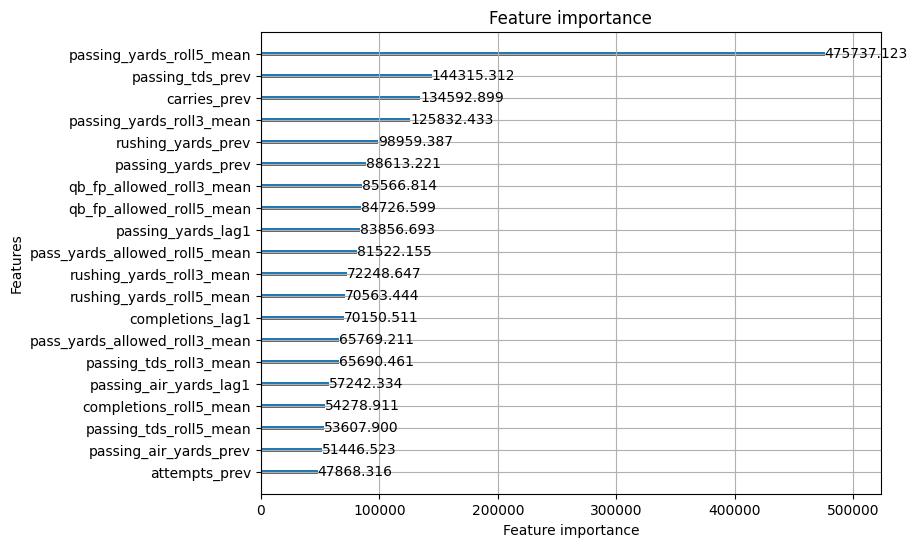

In [75]:
val_pred = model.predict(X_val, num_iteration=model.best_iteration_)
test_pred = model.predict(X_test, num_iteration=model.best_iteration_)


mse = mean_squared_error(y_val, val_pred)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(y_val, val_pred)

print(f"VAL RMSE: {rmse:.4f}")
print(f"VAL MAE : {mae:.4f}")
print("Best iteration:", model.best_iteration_)
lgb.plot_importance(model, max_num_features=20, importance_type='gain', figsize=(8,6))

TEST RMSE: 8.0562
TEST MAE : 6.5390
Best iteration: 93


<Axes: title={'center': 'Feature importance'}, xlabel='Feature importance', ylabel='Features'>

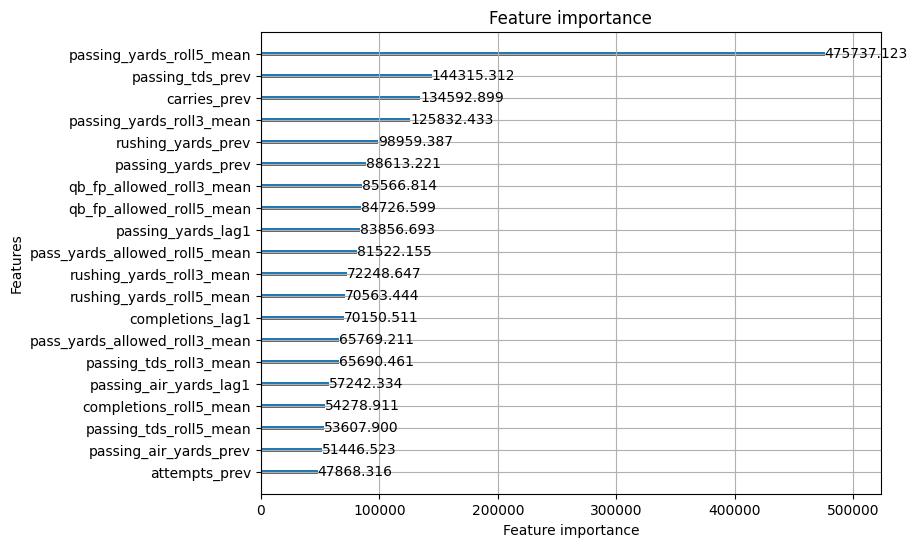

In [76]:
mse = mean_squared_error(y_test, test_pred)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(y_test, test_pred)

print(f"TEST RMSE: {rmse:.4f}")
print(f"TEST MAE : {mae:.4f}")
print("Best iteration:", model.best_iteration_)
lgb.plot_importance(model, max_num_features=20, importance_type='gain', figsize=(8,6))

In [77]:
val_preds_df = keys_val.copy()
val_preds_df["pred_fantasy_points_ppr"] = val_pred
val_preds_df["actual_fantasy_points_ppr"] = y_val.reset_index(drop=True)

val_preds_df.sort_values(["season", "week", "pred_fantasy_points_ppr"], ascending=[True, True, False]).head(20)


,player_id,player_name,season,week,team,opponent_team,pred_fantasy_points_ppr,actual_fantasy_points_ppr
284,00-0034857,J.Allen,2023,1,BUF,NYJ,23.298379,9.04
460,00-0036971,T.Lawrence,2023,1,JAX,IND,22.075563,17.74
415,00-0036389,J.Hurts,2023,1,PHI,NE,21.819060,12.50
72,00-0030565,G.Smith,2023,1,SEA,LA,21.280688,9.08
196,00-0033873,P.Mahomes,2023,1,KC,DET,20.944449,19.54
149,00-0033106,J.Goff,2023,1,DET,KC,18.024413,14.02
432,00-0036442,J.Burrow,2023,1,CIN,CLE,17.997103,3.18
358,00-0035710,D.Jones,2023,1,NYG,DAL,17.145112,4.46
0,00-0023459,A.Rodgers,2023,1,NYJ,BUF,16.449629,0.00
447,00-0036945,J.Fields,2023,1,CHI,GB,16.342831,14.54


In [78]:
test_preds_df = keys_test.copy()
test_preds_df["pred_fantasy_points_ppr"] = test_pred
test_preds_df["actual_fantasy_points_ppr"] = y_test.reset_index(drop=True)

test_preds_df.sort_values(["season", "week", "pred_fantasy_points_ppr"], ascending=[True, True, False]).head(20)

,player_id,player_name,season,week,team,opponent_team,pred_fantasy_points_ppr,actual_fantasy_points_ppr
385,00-0036389,J.Hurts,2024,1,PHI,GB,24.465697,16.42
256,00-0034857,J.Allen,2024,1,BUF,ARI,22.712961,31.18
222,00-0034796,L.Jackson,2024,1,BAL,KC,22.508571,25.12
191,00-0033873,P.Mahomes,2024,1,KC,BAL,19.990662,15.14
431,00-0036971,T.Lawrence,2024,1,JAX,MIA,19.791911,11.28
77,00-0030565,G.Smith,2024,1,SEA,DEN,19.150472,17.84
29,00-0026498,M.Stafford,2024,1,LA,DET,18.661361,14.68
239,00-0034855,B.Mayfield,2024,1,TB,WAS,18.305578,29.66
94,00-0031280,D.Carr,2024,1,NO,CAR,17.735038,21.30
128,00-0033077,D.Prescott,2024,1,DAL,CLE,17.660509,11.46


###### As we can see, the Linear Regression and LightGBM model performances are fairly similar. This is likely due to the fact that the relationship between the features and the target are simple. On our LightGBM model, we achieved an RMSE 7.7 on the validation set and an RMSE of 8 on the testing set. This is actually quite competetive as according to ESPN's paper they achieved an RMSE of 6.78 on the top 500 NFL players. 